In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from skimage import io,color
from skimage.util import img_as_float

# Task-1: Applying FFT on 2D Image


(np.float64(-0.5), np.float64(473.5), np.float64(473.5), np.float64(-0.5))

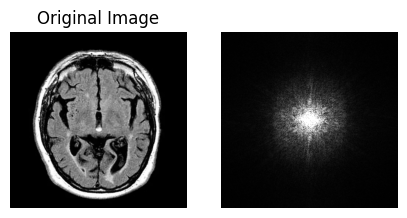

In [2]:
# Load grayscale image brain_mri.png and normalize
img = io.imread('brain_mri.png')
image = img_as_float(img)

def perform_fft2(x, M, N):
    X = np.fft.fft2(x)
    X = np.fft.fftshift(X)
    X = X / (N * M)

    u = np.fft.fftshift(np.fft.fftfreq(M))
    v = np.fft.fftshift(np.fft.fftfreq(N))
    u, v = np.meshgrid(u, v)

    return X, u, v
# Perform FFT on the image
M, N = image.shape
X, u, v = perform_fft2(image, M, N)

plt.figure(figsize=(5,5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(np.log(np.abs(X)+1), cmap='gray',vmin=0, vmax=np.percentile(np.log(np.abs(X)+1), 99))
# The extra argument is given because low frequency content is very dominating in the image.
# If we don't scale properly, we won't be able to visualize other frequency contents.

plt.axis('off')

# Lab Task 2: Filtering in the Frequency Domain


In [3]:
def apply_filter(H, X):
    filtered = X * H
    return np.abs(np.fft.ifft2(np.fft.ifftshift(filtered)))

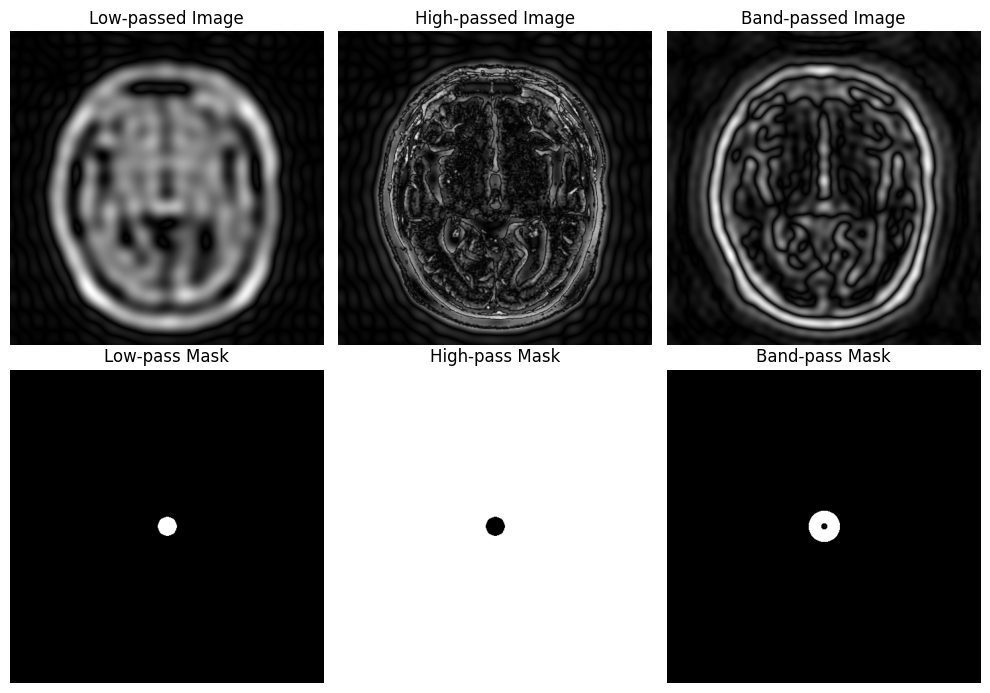

In [4]:
# Compute radial frequency grid
D = np.sqrt(u**2 + v**2)

cut_off = 0.03


# Define a low pass and a high pass filter with the given cut_off

H_lp = (D <= cut_off).astype(float)

H_hp = 1 - H_lp
# Define Band-pass filter with the given cut_offs
thres_low = 0.01
thres_high = 0.05


H_bp = ((D >= thres_low) & (D <= thres_high)).astype(float)
# Apply filter and reconstruct the filtered images
img_lp = apply_filter(H_lp, X)
img_hp = apply_filter(H_hp, X)
img_bp = apply_filter(H_bp, X)

plt.figure(figsize=(10, 7))

plt.subplot(2, 3, 1)
plt.imshow(img_lp, cmap='gray')
plt.title("Low-passed Image")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(img_hp, cmap='gray')
plt.title("High-passed Image")
plt.axis('off')

plt.subplot(2, 3,3)
plt.imshow(img_bp, cmap='gray')
plt.title("Band-passed Image")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(H_lp, cmap='gray')
plt.title("Low-pass Mask")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(H_hp, cmap='gray')
plt.title("High-pass Mask")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(H_bp, cmap='gray')
plt.title("Band-pass Mask")
plt.axis('off')

plt.tight_layout()
plt.show()

Explain the effects of the filters in your own words (based on what you observe visually).

A low-pass filter lets only the low frequencies pass through, which means it keeps the smooth and slowly changing parts of the image. Any frequency below the cutoff value of 0.03 is allowed, while higher frequencies are removed. Because of this, the image looks blurred or smoothed. Fine details, sharp edges, and high-frequency noise are reduced or removed. If we look at the mask, we will see a bright circular area in the center. This bright center represents the DC component and other low frequencies that are being kept.

A high-pass filter works in the opposite way. It blocks the low frequencies and allows only the high frequencies to pass. This makes edges, textures, and fine details more visible. Since the low-frequency part, including the DC component (which represents the average brightness), is removed, the filtered image usually looks darker overall. What stands out are the sharp transitions and boundaries, such as the edges in the brain MRI image. The mask for the high-pass filter looks like the opposite of the low-pass mask, with a dark center and brighter outer areas.

A band-pass filter allows only a certain range of frequencies to pass, in this case between 0.01 and 0.05. It blocks both very low and very high frequencies. This means it keeps the middle range frequencies, which often contain important structural details. It is useful when we want to focus on specific patterns or features in the image. The mask looks like a bright ring, showing the range of frequencies that are allowed. The filtered image keeps some structure but removes both the very smooth background and the very fine details.